# Meteorite Landings EDA

Exploratory analysis of `Meteorite_Landings_cleaned.csv` using `pandas` and `matplotlib`.

In [14]:
%matplotlib inline

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [15]:
data_path = Path("../viz_design/Meteorite_Landings_cleaned.csv")
df = pd.read_csv(data_path)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["mass_g"] = pd.to_numeric(df["mass_g"], errors="coerce")
df["reclat"] = pd.to_numeric(df["reclat"], errors="coerce")
df["reclong"] = pd.to_numeric(df["reclong"], errors="coerce")

eda_df = df.dropna(subset=["year", "mass_g", "reclat", "reclong", "recclass", "fall"]).copy()
eda_df = eda_df[(eda_df["year"] >= 860) & (eda_df["year"] <= 2025)]

print(f"Rows: {len(eda_df):,} | Columns: {eda_df.shape[1]}")
eda_df.head()

Rows: 31,911 | Columns: 10


,name,id,nametype,recclass,mass_g,fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902,-33.16667,-64.95000,"(-33.16667, -64.95)"


In [16]:
import pandas as pd
from ydata_profiling import ProfileReport

df = pd.read_csv("meteorites.csv")

profile = ProfileReport(df, title="Meteorite EDA Report")
profile.to_file("eda/report.html")

FileNotFoundError: [Errno 2] No such file or directory: 'meteorites.csv'

In [ ]:
print("Data types")
print(eda_df.dtypes)

print("\nSummary statistics (numeric)")
display(eda_df[["year", "mass_g", "reclat", "reclong"]].describe())

print("\nFall vs Found")
display(eda_df["fall"].value_counts())

print("\nTop meteorite classes")
display(eda_df["recclass"].value_counts().head(10))

Data types
name            object
id               int64
nametype        object
recclass        object
mass_g         float64
fall            object
year             int64
reclat         float64
reclong        float64
GeoLocation     object
dtype: object

Summary statistics (numeric)


,year,mass_g,reclat,reclong
count,31911.000000,3.191100e+04,31911.000000,31911.000000
mean,1986.983611,1.855334e+04,-47.325541,73.217418
std,26.723522,6.870431e+05,46.668084,83.196982
min,860.000000,1.000000e-02,-87.366670,-165.433330
25%,1982.000000,6.500000e+00,-79.683330,26.000000
50%,1991.000000,2.968000e+01,-72.000000,56.837750
75%,2000.000000,2.021050e+02,18.321420,159.394165
max,2013.000000,6.000000e+07,81.166670,178.200000



Fall vs Found


fall
Found    30847
Fell      1064
Name: count, dtype: int64


Top meteorite classes


recclass
L6      6523
H5      5586
H4      3324
H6      3231
L5      2723
LL5     1897
LL6      963
L4       799
H4/5     380
CM2      279
Name: count, dtype: int64

## 1) Meteorite records over time

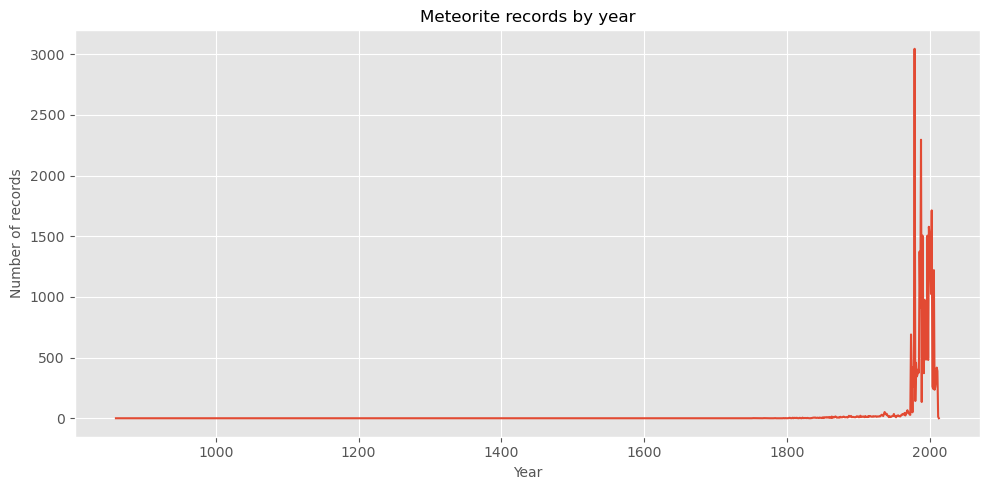

In [ ]:
records_per_year = eda_df.groupby("year").size().sort_index()

fig, ax = plt.subplots()
ax.plot(records_per_year.index, records_per_year.values, linewidth=1.5)
ax.set_title("Meteorite records by year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

## 2) Fell vs Found trend by decade

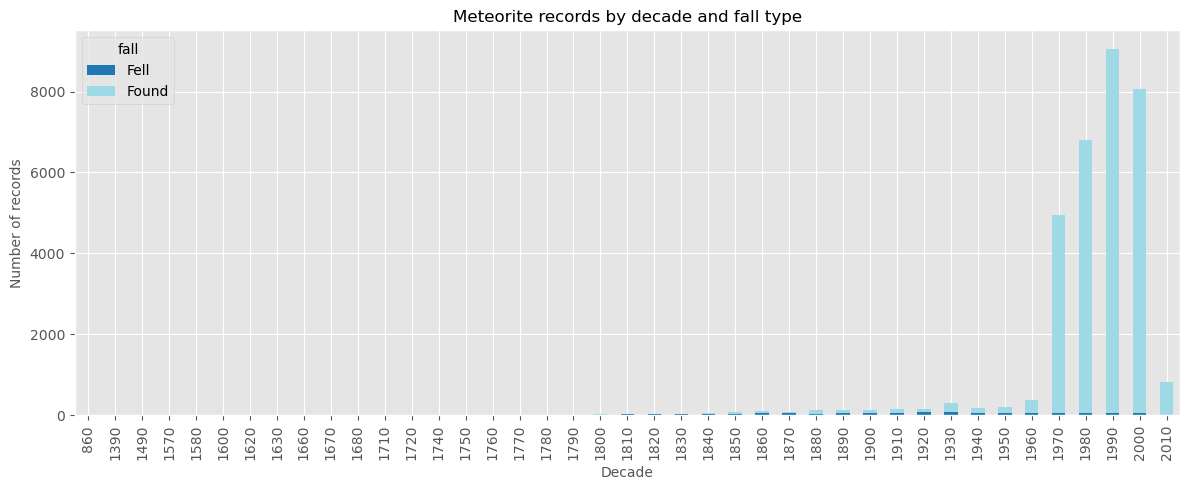

In [ ]:
decade_df = eda_df.copy()
decade_df["decade"] = (decade_df["year"] // 10 * 10).astype(int)
fall_by_decade = (
    decade_df.groupby(["decade", "fall"]).size().unstack(fill_value=0).sort_index()
)

ax = fall_by_decade.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab20")
ax.set_title("Meteorite records by decade and fall type")
ax.set_xlabel("Decade")
ax.set_ylabel("Number of records")
plt.tight_layout()
plt.show()

## 3) Most frequent meteorite classes

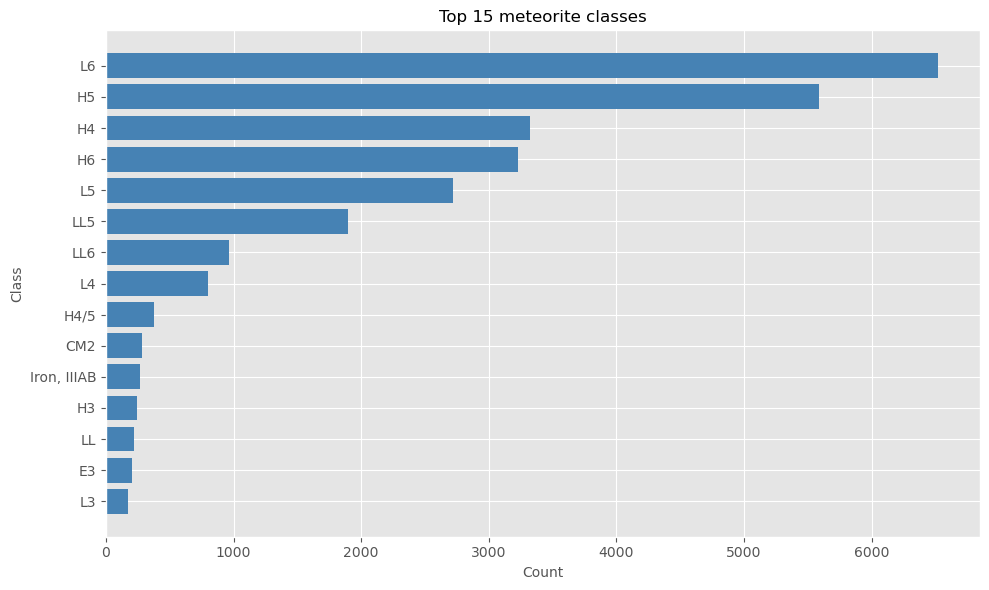

In [ ]:
top_classes = eda_df["recclass"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_classes.index, top_classes.values, color="steelblue")
ax.set_title("Top 15 meteorite classes")
ax.set_xlabel("Count")
ax.set_ylabel("Class")
plt.tight_layout()
plt.show()

## 4) Mass distribution (highly skewed)

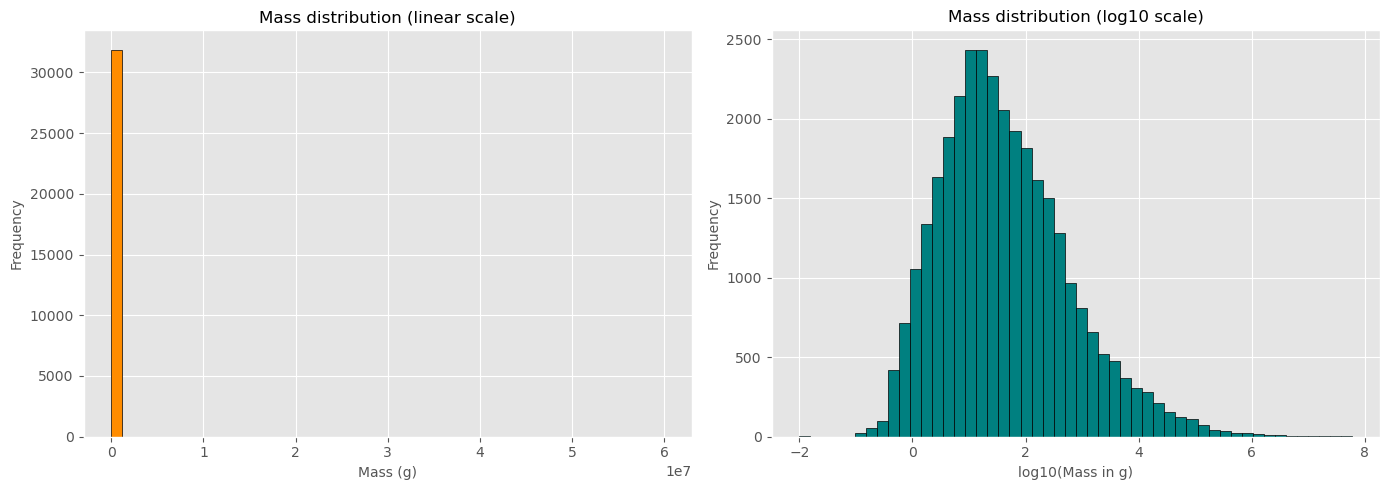

In [ ]:
mass = eda_df["mass_g"].clip(lower=0.01)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(mass, bins=50, color="darkorange", edgecolor="black")
axes[0].set_title("Mass distribution (linear scale)")
axes[0].set_xlabel("Mass (g)")
axes[0].set_ylabel("Frequency")

axes[1].hist(np.log10(mass), bins=50, color="teal", edgecolor="black")
axes[1].set_title("Mass distribution (log10 scale)")
axes[1].set_xlabel("log10(Mass in g)")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 5) Geospatial distribution (latitude vs longitude)

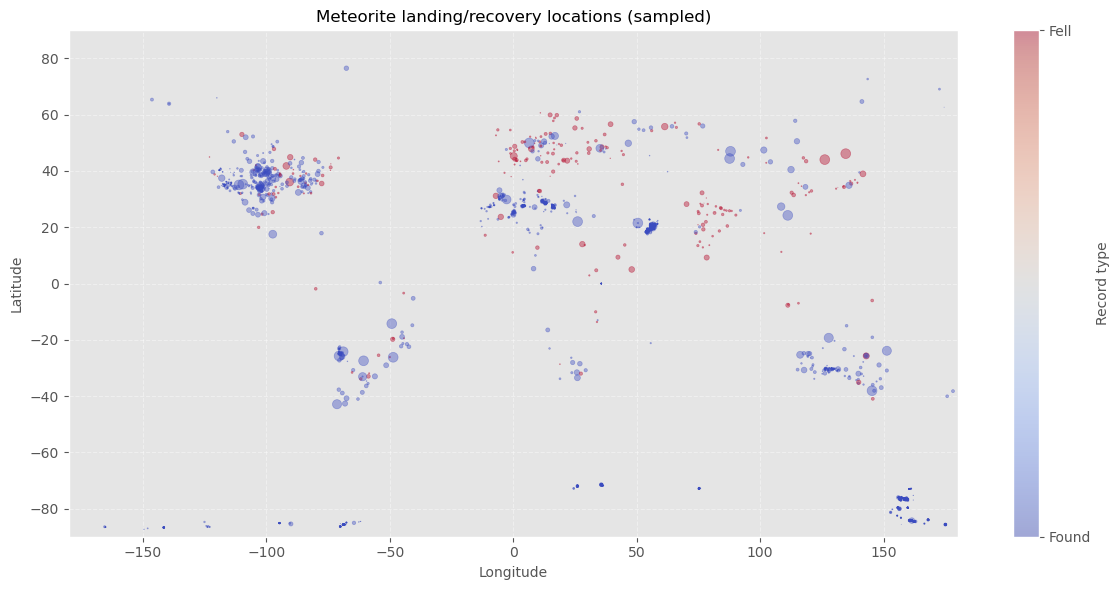

In [ ]:
sample_for_map = eda_df.sample(min(7000, len(eda_df)), random_state=42)
sizes = np.sqrt(sample_for_map["mass_g"].clip(lower=1).clip(upper=1_000_000)) / 20

fig, ax = plt.subplots(figsize=(12, 6))
scatter = ax.scatter(
    sample_for_map["reclong"],
    sample_for_map["reclat"],
    c=(sample_for_map["fall"] == "Fell").astype(int),
    s=sizes,
    alpha=0.4,
    cmap="coolwarm",
)

ax.set_title("Meteorite landing/recovery locations (sampled)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.grid(True, linestyle="--", alpha=0.4)

cbar = plt.colorbar(scatter, ax=ax, ticks=[0, 1])
cbar.ax.set_yticklabels(["Found", "Fell"])
cbar.set_label("Record type")

plt.tight_layout()
plt.show()

## 6) Mass by fall type

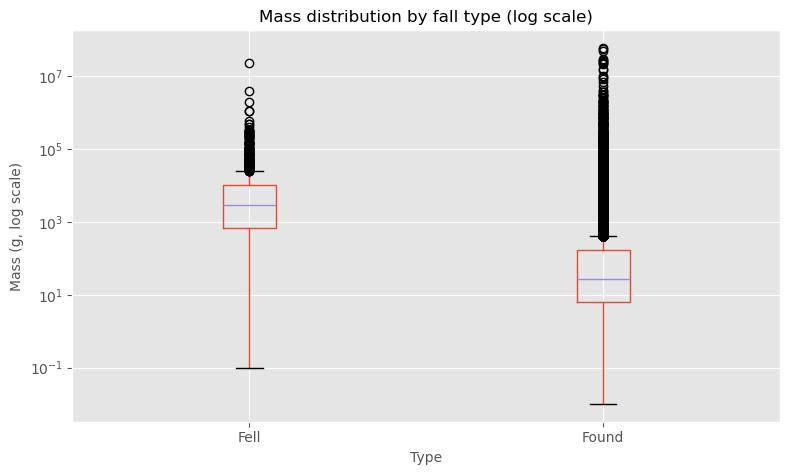

In [ ]:
box_df = eda_df[eda_df["fall"].isin(["Found", "Fell"])].copy()
box_df["mass_g"] = box_df["mass_g"].clip(lower=0.01)

fig, ax = plt.subplots(figsize=(8, 5))
box_df.boxplot(column="mass_g", by="fall", ax=ax)
ax.set_yscale("log")
ax.set_title("Mass distribution by fall type (log scale)")
ax.set_xlabel("Type")
ax.set_ylabel("Mass (g, log scale)")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [39]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

# -----------------------------
# 📂 Daten laden
# -----------------------------
df = pd.read_csv("Meteorite_Landings.csv")

# -----------------------------
# 🔧 Spalten anpassen
# -----------------------------
df["mass (g)"] = pd.to_numeric(df["mass (g)"], errors="coerce")
df["year"] = pd.to_numeric(df["year"], errors="coerce")

df["log_mass"] = np.log1p(df["mass (g)"])

# 👉 Reihenfolge fixen
cols = list(df.columns)
cols.remove("log_mass")
mass_index = cols.index("mass (g)")
cols.insert(mass_index + 1, "log_mass")
df = df[cols]

# -----------------------------
# 📈 PROFILE REPORT
# -----------------------------
profile = ProfileReport(
    df,
    title="Meteorite Report",
    minimal=False,
    plot={"histogram": {"bins": 80}},
    vars={
        "num": {
            "quantiles": [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
        }
    },
    interactions=None,
    correlations=None,
)

profile.to_file("meteorite_report.html")

print("✅ Report mit mass & log_mass nebeneinander!")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Report mit mass & log_mass nebeneinander!


In [23]:
import pandas as pd
import numpy as np
from ydata_profiling import ProfileReport

# Daten laden
df = pd.read_csv("Meteorite_Landings.csv")
df

,name,id,nametype,recclass,mass (g),fall,year,reclat,reclong,GeoLocation
0,Aachen,1,Valid,L5,21.0,Fell,1880.0,50.77500,6.08333,"(50.775, 6.08333)"
1,Aarhus,2,Valid,H6,720.0,Fell,1951.0,56.18333,10.23333,"(56.18333, 10.23333)"
2,Abee,6,Valid,EH4,107000.0,Fell,1952.0,54.21667,-113.00000,"(54.21667, -113.0)"
3,Acapulco,10,Valid,Acapulcoite,1914.0,Fell,1976.0,16.88333,-99.90000,"(16.88333, -99.9)"
4,Achiras,370,Valid,L6,780.0,Fell,1902.0,-33.16667,-64.95000,"(-33.16667, -64.95)"
...,...,...,...,...,...,...,...,...,...,...
45711,Zillah 002,31356,Valid,Eucrite,172.0,Found,1990.0,29.03700,17.01850,"(29.037, 17.0185)"
45712,Zinder,30409,Valid,"Pallasite, ungrouped",46.0,Found,1999.0,13.78333,8.96667,"(13.78333, 8.96667)"
45713,Zlin,30410,Valid,H4,3.3,Found,1939.0,49.25000,17.66667,"(49.25, 17.66667)"
45714,Zubkovsky,31357,Valid,L6,2167.0,Found,2003.0,49.78917,41.50460,"(49.78917, 41.5046)"
